**1. Introdução**

**Otimização de Conversão:**

Teste A/B em Vitrine de E-commerce
Este projeto analisa a eficácia de uma nova vitrine de produtos. Através de um teste rigoroso, validamos se a mudança deve ser implementada para todo o site, garantindo decisões baseadas em dados e não em intuição.

In [16]:
import pandas as pd              # Para manipular tabelas de dados (DataFrames)
import numpy as np               # Para cálculos matemáticos
from scipy import stats          # Para a estatística avançada (o teste T)
import matplotlib.pyplot as plt  # Para criar gráficos
import seaborn as sns            # Para deixar os gráficos mais bonitos

In [5]:
np.random.seed(42) # dados ficticios

#grupos
#1000 visitas com media de conversão de 10 e 12%
grupo_a = np.random.binomial(n=1,p=0.10, size=3835)
grupo_b = np.random.binomial(n=1, p=0.12, size=3835)

df = pd.DataFrame({ 'grupo': ['A'] * 3835 + ['B'] * 3835,
                   'comprou': np.concatenate([grupo_a, grupo_b])
})
df.head()

,grupo,comprou
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0


In [6]:
resultados = df.groupby('grupo')['comprou'].mean()

print(resultados)

grupo
A    0.095958
B    0.117340
Name: comprou, dtype: float64


O grupo B teve maior taxa de conversão. as será que essa diferença foi real ou foi apenas sorte (acaso)?  

Para responder a isso, calculamos o P-valor (p-value). Ele nos diz a probabilidade de esse resultado ter acontecido por pura coincidência.

In [7]:
df_a = df[df['grupo'] == 'A']['comprou']
df_b = df[df['grupo'] == 'B']['comprou']

t_stats, p_valor = stats.ttest_ind(df_a, df_b)

print(f"P-valor: {p_valor:.4f}")

P-valor: 0.0024


se o p-valor for menor que 0.05 (5%), consideramos que a diferença é estatisticamente significativa (ou seja, é real e não sorte).

Regra dos 5%:

* P_valor > 0.05: A diferença não é significativa. O resultado aconteceu por acaso ou sorte. Ou seja, Inconclusivo.

* P_valor < 0.05: A diferença é Estatisticamente Significativa. É muito provavel que o Grupo B seja realmente melhor.

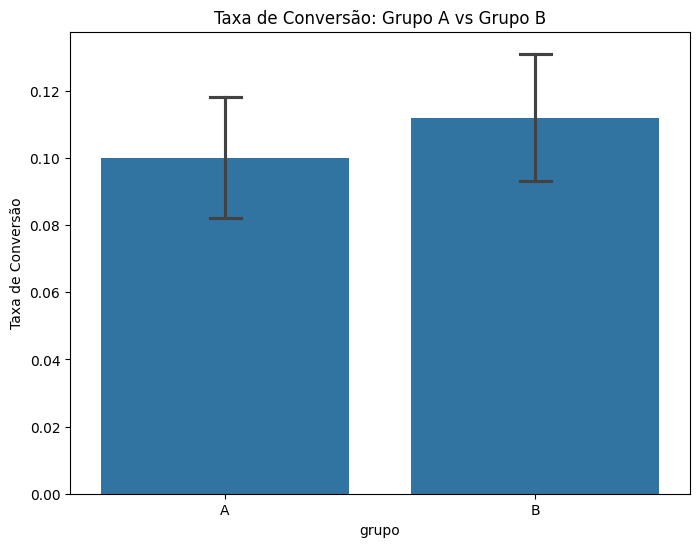

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(x='grupo', y='comprou', data=df, errorbar=('ci',95), capsize=.1)

plt.title('Taxa de Conversão: Grupo A vs Grupo B')
plt.ylabel('Taxa de Conversão')
plt.show()

Se essas linhas se cruzam, isso confirma visualmente o que o P-valor nos disse: que a diferença entre eles pode ser apenas acaso.

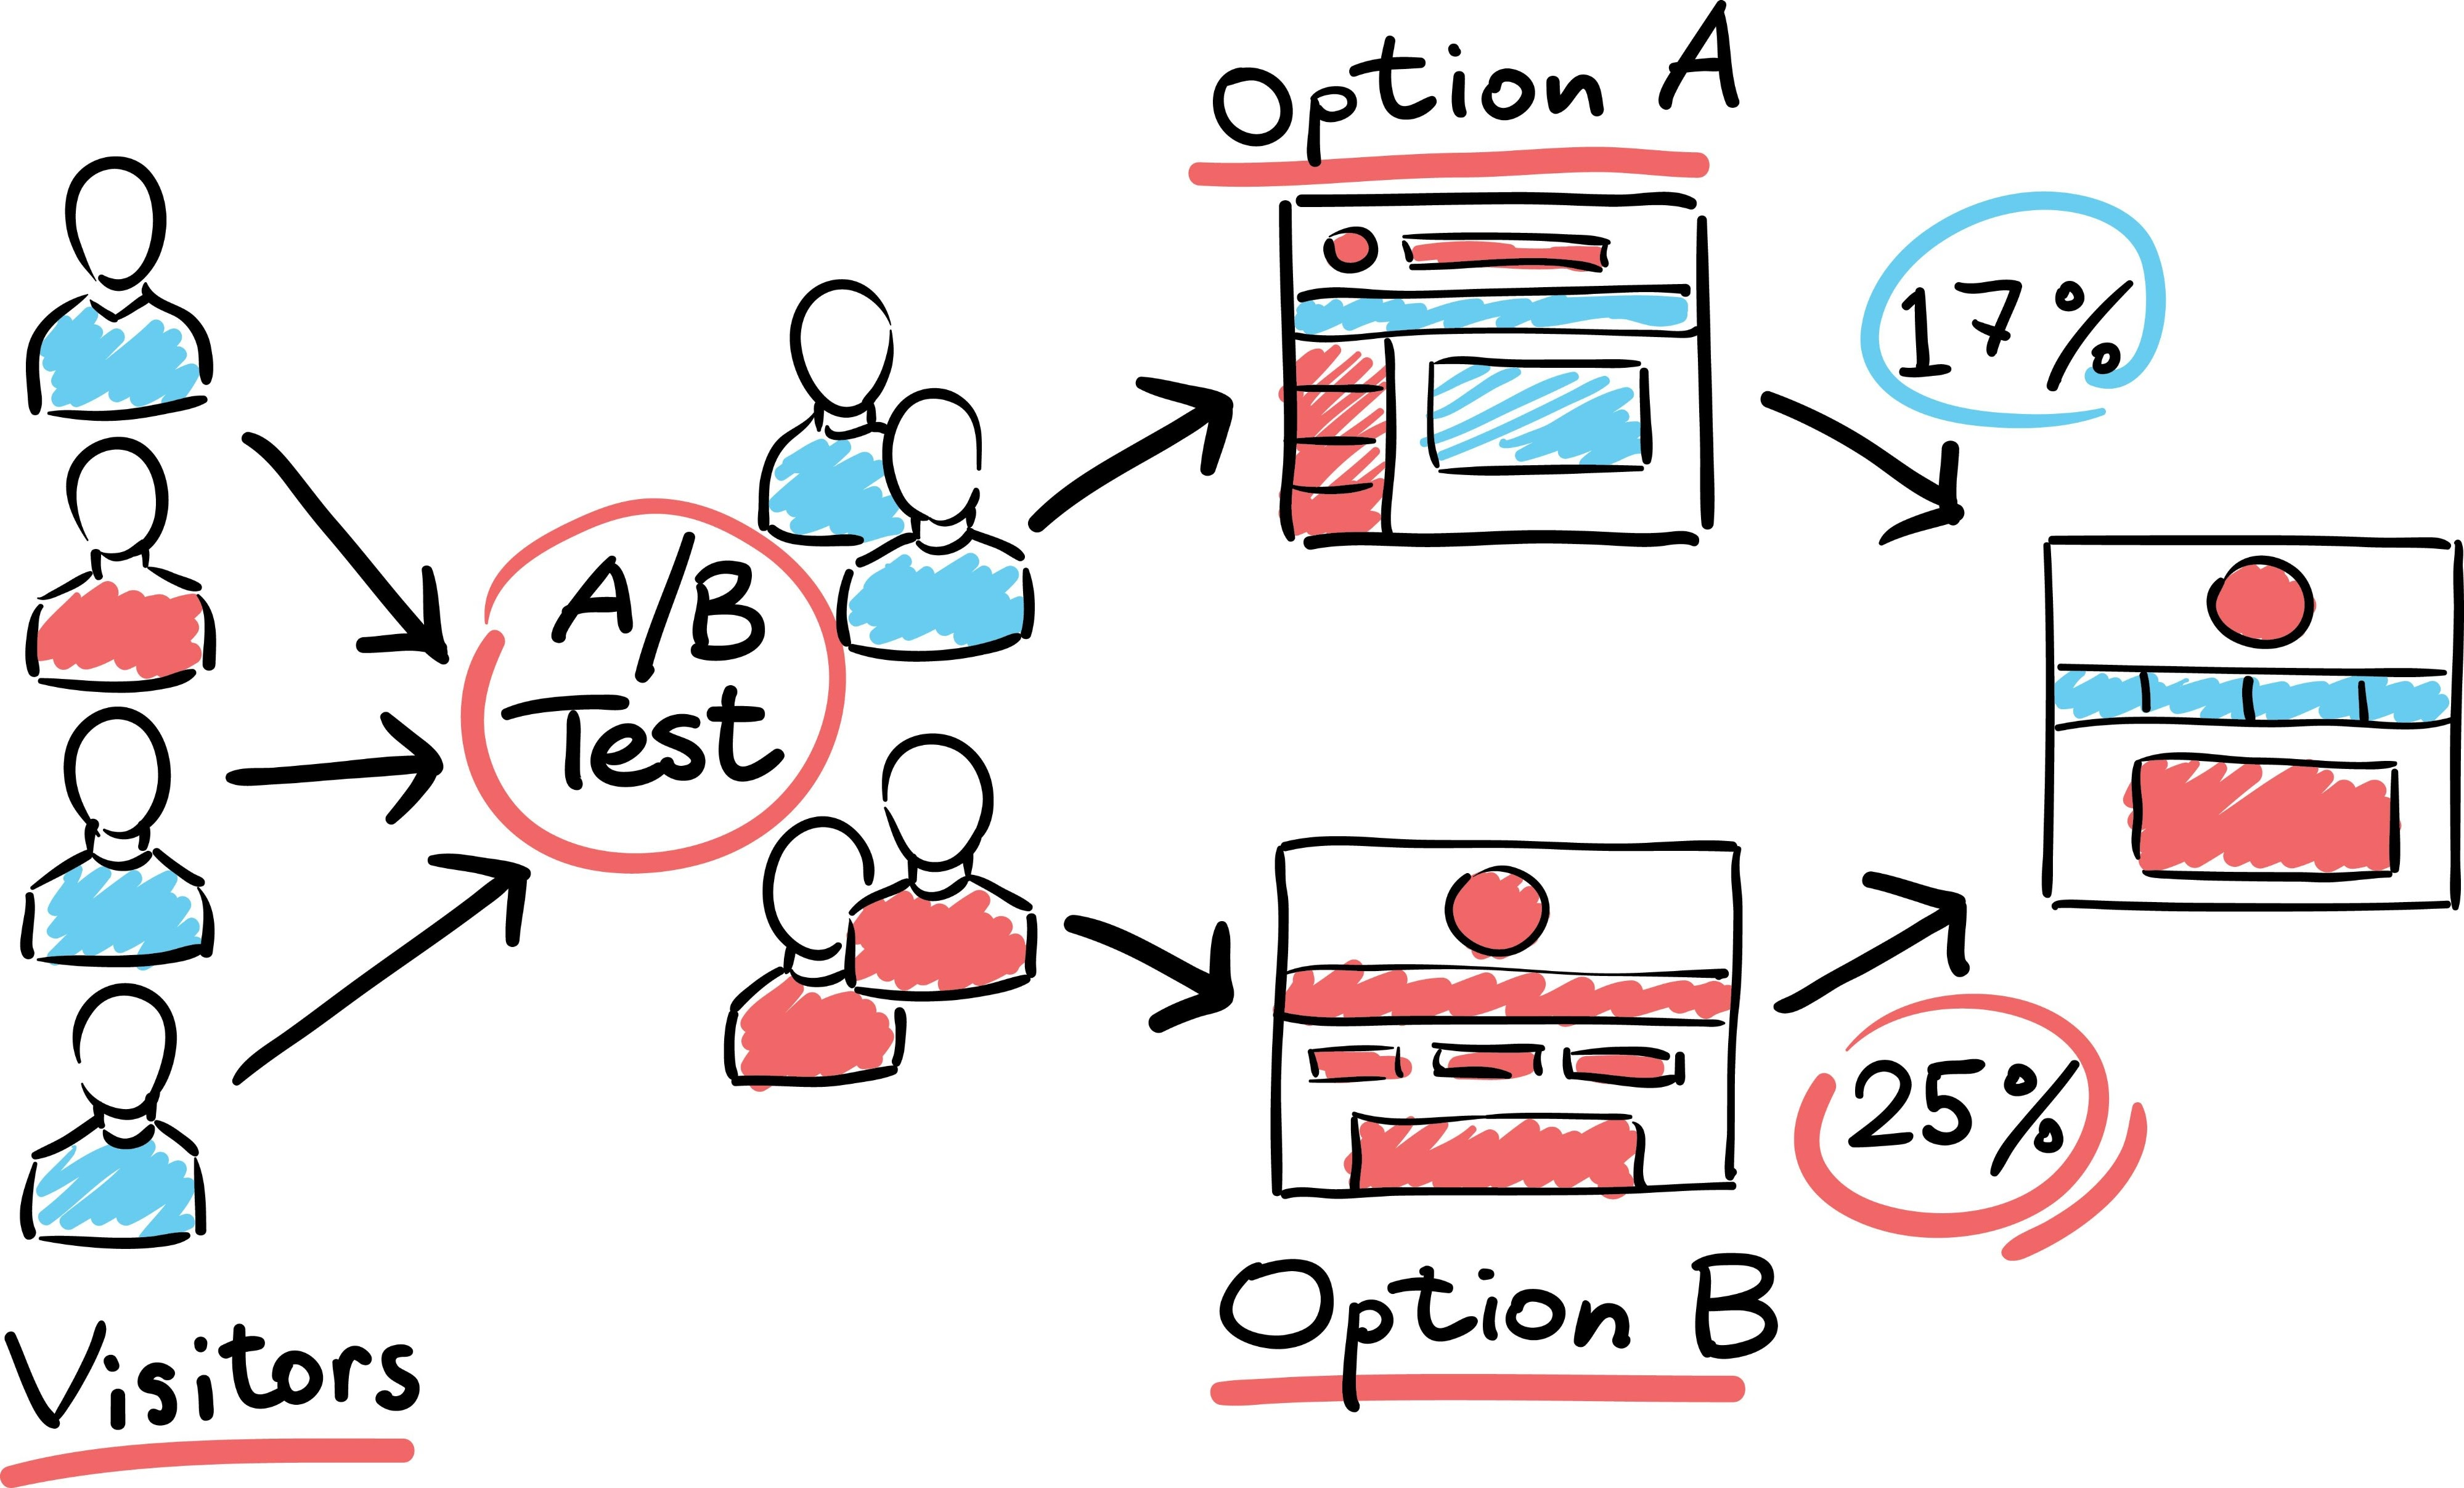

Um teste robusto se apoia em três pilares principais:

1. Design Estatístico (Power Analysis):
Determinar o tamanho da amostra antes de começar, para garantir que temos "lente" suficiente para ver a diferença (evitando o erro que vimos na simulação anterior).

2. Engenharia de Atribuição: Como garantir que o usuário que caiu no Grupo A sempre veja A (consistência) e que a divisão seja realmente 50/50 (evitando viés).

3. Instrumentação à Prova de Falhas: Garantir que estamos medindo exatamente o que achamos que estamos medindo (evitando o Sample Ratio Mismatch - SRM).

**2. O Planejamento**



MDE É a menor melhoria que você decide que vale a pena detectar.
* Exemplo: Se a sua taxa de conversão hoje é 10%, você quer rodar um teste para detectar qualquer melhoria que leve isso para 10.1% (MDE pequeno) ou você só se importa se a conversão subir para 15% (MDE grande)?


  - Se a mudança for gigante, você percebe rapido e com poucas pessoas,
  - Se a mudança for sutil, ela se mistura fácil com a variação natural do dia a dia. Para ter certeza que não foi sorte, você precisa de muito mais dados.

  **Quanto menor o efeito que você quer detectar (MDE), MAIOR precisa ser a sua amostra.**

  

**1. Nível de Significância ($\alpha$ ou Alpha)**

Lembra do p-valor < 0.05 que usamos antes? Esse 0.05 (ou 5%) é o Nível de Significância padrão do mercado.

**2. Poder Estatístico (Power ou $1 - \beta$)**

O padrão de mercado é 80%. Ou seja, queremos ter 80% de certeza de que, se houver uma melhoria, nós vamos encontrá-la.

* Alpha: 5% (0.05)

* Power: 80% (0.80)

* MDE: Vamos definir que queremos detectar uma melhoria mínima de 2% na conversão (de 10% para 12%, por exemplo).




Agora traduzindo isso para o código, vamos descobrir quantas pessoas você realmente precisa "convencer" a entrar no seu site.

Para isso, vamos usar a biblioteca statsmodels. Ela tem uma função específica que faz o trabalho pesado de calcular o tamanho da amostra (Sample Size) baseado no poder estatístico que definimos.



**Passo 1: O Cálculo do "Effect Size"**

Antes de calcular o número de pessoas, o Python precisa entender a "distância" estatística entre 10% e 12%. Chamamos isso de Effect Size (Tamanho do Efeito).

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower


# 1. Definindo nossas Baselines -- taxas de conversão
taxa_controle = 0.10
taxa_variante = 0.12

# 2. Calculando o "Effect Size"
effect_size = sms.proportion_effectsize(taxa_controle, taxa_variante)

# 3. Calculando o Sample Size

# alpha=0.05 (significância), power=0.8 (poder), ratio=1 (mesmo tamanho para os dois grupos)
tamanho_amostra = NormalIndPower().solve_power(
    effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1
)

print(f"Effect Size calculado: {effect_size:.4f}")
print(f"Tamanho da amostra necessário por grupo: {tamanho_amostra:.0f}")

Effect Size calculado: -0.0640
Tamanho da amostra necessário por grupo: 3835


*O que aprendemos aqui:*

Antes (N=1000): O teste dizia "Sorte".

Agora (N=3835): O teste diz "Vitória Estatística".

**Pilar 2: Engenharia de Atribuição (Hashing)**

Evitar a esposição de um usuario à duas versões para ter um resultado mais consistente.
Precisamos de um método de divisão que seja Aleatório, mas também Determinístico.

* Resto 0: O usuário vai para o Grupo A (Controle).

* Resto 1: O usuário vai para o Grupo B (Variante).

In [ ]:
import zlib

def definir_grupo(user_id):
    # 1. Transforma o ID em string e depois em bytes (necessário para o hash)
    id_bytes = str(user_id).encode('utf-8')

    # 2. Gera um número gigante único para esse ID (o Hash)
    hash_num = zlib.crc32(id_bytes)

    # 3. Verifica o resto da divisão por 2 (0 ou 1)
    if hash_num % 2 == 0:
        return 'A'
    else:
        return 'B'

# Testando com alguns usuários
print(f"User 100 vai para: {definir_grupo(100)}")
print(f"User 101 vai para: {definir_grupo(101)}")
print(f"User 'agatha' vai para: {definir_grupo('agatha')}")

User 100 vai para: A
User 101 vai para: A
User 'agatha' vai para: A


In [ ]:
import random

# 1. Criamos contadores para cada grupo
contagem_a = 0
contagem_b = 0

# 2. Vamos simular 10.000 usuários
total_usuarios = 10000

for _ in range(total_usuarios):
    # Geramos um ID aleatório (simulando um user_id real)
    id_usuario = random.randint(1, 1000000)

    # Passamos pela nossa "máquina de hash"
    grupo = definir_grupo(id_usuario)

    # 3. Contamos o resultado
    if grupo == 'A':
        contagem_a += 1
    else:
        contagem_b += 1

# 4. Mostramos o placar final
print(f"Total Grupo A: {contagem_a}")
print(f"Total Grupo B: {contagem_b}")
print(f"Proporção A: {contagem_a / total_usuarios:.2%}")
print(f"Proporção B: {contagem_b / total_usuarios:.2%}")

Total Grupo A: 4948
Total Grupo B: 5052
Proporção A: 49.48%
Proporção B: 50.52%


1. **Aleatória:** Ela divide o público quase perfeitamente ao meio.

2. **Determinística:** Se o usuário user_123 voltar amanhã, o cálculo crc32 dele será idêntico, e ele cairá no mesmo grupo.



**Pilar 3: A Armadilha Invisível (SRM)**

Agora que garantimos o Design (Cálculo de Amostra) e a Atribuição (Hashing), falta o último perigo que derruba muitos testes profissionais: o SRM (Sample Ratio Mismatch).

In [12]:
dados = df.groupby('grupo')['comprou'].mean()

print(dados)

grupo
A    0.095958
B    0.117340
Name: comprou, dtype: float64


Lá no código, nós definimos p=0.10 para o A e p=0.12 para o B. Por que você acha que o resultado final não deu exatamente 10% e 12% cravados?

O acaso é "teimoso".

Você pode jogar a moeda 10 vezes e sair 7 Coroas e 3 Caras. Isso não significa que a moeda está estragada, é apenas a Variação Natural (ou Variação Amostral) agindo.

O **Lift** é exatamente essa segunda medida: ele nos diz o impacto proporcional da mudança. Ele responde à pergunta: "Em relação ao que a gente já tinha, o quanto melhoramos?"

In [15]:
taxa_a = dados['A']
taxa_b = dados['B']

lift = (taxa_b - taxa_a)/taxa_a

print(f"Lift: {lift:.2%}")

Lift: 22.28%


**1. O Vencedor:** Grupo B.

**2. A Certeza:** P-valor de 0,0024 (super confiável).

**3. O Impacto:** Lift de 22,28%.


Recomendo a implementação da Versão B, que gerou um aumento de 22% na conversão com 99,7% de confiança estatística.

In [ ]:
from google.colab import drive
from google.colab import userdata
import os

# 1. Garante que o Drive está montado
drive.mount('/content/drive')

# --- DEFININDO OS CAMINHOS ---
pasta_git = "/content/drive/MyDrive/ABTest/"
origem_notebook = "/content/drive/MyDrive/Colab Notebooks/Teste_AB.ipynb"

# 2. Entra na pasta do Git
os.chdir(pasta_git)
print(f"📍 Agora estamos na pasta: {os.getcwd()}")

# 3. CRIA O ARQUIVO README.md (O 'Head') SEPARADO
# Aqui escrevemos o conteúdo dele direto num arquivo novo
conteudo_readme = """# 🛒 Projeto: Validação de Nova Vitrine de E-commerce (Teste A/B)

## 📌 Objetivo do Projeto
Este projeto simula e analisa um cenário real de e-commerce onde uma nova interface de vitrine foi testada. O objetivo foi verificar se a nova versão (Grupo B) traz um aumento estatisticamente significativo na taxa de conversão em relação à versão atual (Grupo A).

## 🛠️ Ferramentas Utilizadas
* **Python** (Pandas, Numpy) para manipulação de dados.
* **SciPy** para cálculos de estatística inferencial (P-valor e Teste T).
* **Matplotlib/Seaborn** para visualização de dados.
* **Hashing (CRC32)** para atribuição consistente de usuários.

## 📊 Principais Descobertas
* **Lift de Conversão:** A nova vitrine gerou um aumento de **22,28%** nas vendas.
* **Confiança Estatística:** O P-valor de **0,0024** confirma que o resultado não foi por acaso (Nível de confiança de 99,7%).
* **Tamanho de Amostra:** O teste foi dimensionado para detectar um efeito mínimo de 2%, garantindo a robustez da análise.

## 🚀 Conclusão
Com base nos dados, a recomendação é a **implementação imediata da nova vitrine**, dado que o ganho de 22% na conversão representa um impacto financeiro direto e seguro.
"""

with open("README.md", "w") as f:
    f.write(conteudo_readme)
print("📄 Arquivo README.md criado com sucesso!")

# 4. Copia o notebook (O 'Corpo') para ficar ao lado do README
!cp "{origem_notebook}" "{pasta_git}"
print("📘 Notebook atualizado copiado para a pasta.")

# 5. Configura e Envia tudo para o GitHub
!git config --global user.email "agathabarros@example.com"
!git config --global user.name "Agatha B"

token = userdata.get('GITHUB_TOKEN')
username = "agathabarros" # Confirme se seu usuário é este mesmo
repo = "ABTest"

print("📦 Enviando para o GitHub...")
!git add .
!git commit -m "Adicionando README e Notebook separadamente"
!git push https://{token}@github.com/{username}/{repo}.git main

print("✅ Feito! Confira no GitHub: agora deve ter 2 arquivos lá.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📍 Agora estamos na pasta: /content/drive/MyDrive/ABTest
📄 Arquivo README.md criado com sucesso!
📘 Notebook atualizado copiado para a pasta.
📦 Enviando para o GitHub...
[main 61ebc34] Adicionando README e Notebook separadamente
 2 files changed, 14 insertions(+), 14 deletions(-)
 rewrite README.md (91%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.49 KiB | 127.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/agathabarros/ABTest.git
   6ee73ea..61ebc34  main -> main
✅ Feito! Confira no GitHub: agora deve ter 2 arquivos lá.
